# Análisis Exploratorio de Datos — Wine Quality Dataset

Propiedades fisicoquímicas y calidad sensorial de 6,497 muestras de vino verde
portugués (Vinho Verde), tinto y blanco. Fuente: P. Cortez et al., *Wine Quality*
dataset, UCI Machine Learning Repository.

**Requisito:** coloca `winequality-red.csv` y `winequality-white.csv` en la
misma carpeta que este notebook antes de ejecutarlo.

**Contenido:**
1. Carga y vista general
2. Datos faltantes
3. Filas duplicadas
4. Estadísticas descriptivas
5. Distribuciones
6. Valores atípicos (outliers)
7. Correlaciones
8. Tinto vs. Blanco
9. Calidad por tipo de vino
10. Conclusiones


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Paleta temática: bordeaux para tinto, dorado para blanco
COLOR_RED = "#7B1E32"
COLOR_WHITE = "#C9A94A"
PALETTE = {"red": COLOR_RED, "white": COLOR_WHITE}

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#E4DFD6", "grid.color": "#E4DFD6",
})
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


## 1. Carga y vista general del dataset

In [2]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")
red["tipo_vino"] = "red"
white["tipo_vino"] = "white"

df = pd.concat([red, white], ignore_index=True)
features = [c for c in df.columns if c not in ("tipo_vino", "quality")]

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
print(f"Tinto: {len(red)} ({len(red)/len(df):.1%})  |  Blanco: {len(white)} ({len(white)/len(df):.1%})")
df.head()


Filas: 6497  |  Columnas: 13
Tinto: 1599 (24.6%)  |  Blanco: 4898 (75.4%)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo_vino
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  tipo_vino             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## 2. Datos faltantes

Se revisan las 13 columnas en busca de valores nulos.


In [4]:
missing = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "pct_faltantes": (df.isna().sum() / len(df) * 100).round(2),
})
missing


,n_faltantes,pct_faltantes
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


> **Resultado:** no hay valores faltantes en ninguna columna. Es un dataset
> curado — no se requiere imputación ni descarte de filas por esta razón.


## 3. Filas duplicadas

A diferencia de los nulos, aquí sí aparece un problema real de calidad de datos.


In [5]:
dup_total = df.duplicated().sum()
dup_red = red.duplicated().sum()
dup_white = white.duplicated().sum()

dup_summary = pd.DataFrame({
    "subset": ["red", "white", "combinado"],
    "n_filas": [len(red), len(white), len(df)],
    "n_duplicados": [dup_red, dup_white, dup_total],
    "pct_duplicados": [
        round(dup_red / len(red) * 100, 2),
        round(dup_white / len(white) * 100, 2),
        round(dup_total / len(df) * 100, 2),
    ],
})
dup_summary


,subset,n_filas,n_duplicados,pct_duplicados
0,red,1599,240,15.01
1,white,4898,937,19.13
2,combinado,6497,1177,18.12


> **18% del dataset combinado son filas 100% duplicadas** (más frecuente en
> blancos que en tintos). **Importante:** si vas a usar este dataset para
> entrenar y evaluar modelos con `train_test_split` o `cross_validation`,
> considera `df.drop_duplicates()` antes — los duplicados pueden filtrarse
> entre folds e inflar artificialmente las métricas.


## 4. Estadísticas descriptivas

In [6]:
desc = df[features + ["quality"]].describe().T
desc


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [7]:
medias_por_tipo = df.groupby("tipo_vino")[features + ["quality"]].mean().T
medias_por_tipo.columns = ["media_red", "media_white"]
medias_por_tipo.round(3)


,media_red,media_white
fixed acidity,8.320,6.855
volatile acidity,0.528,0.278
citric acid,0.271,0.334
residual sugar,2.539,6.391
chlorides,0.087,0.046
free sulfur dioxide,15.875,35.308
total sulfur dioxide,46.468,138.361
density,0.997,0.994
pH,3.311,3.188
sulphates,0.658,0.490


## 5. Distribuciones

Histograma de cada variable, coloreado por tipo de vino.


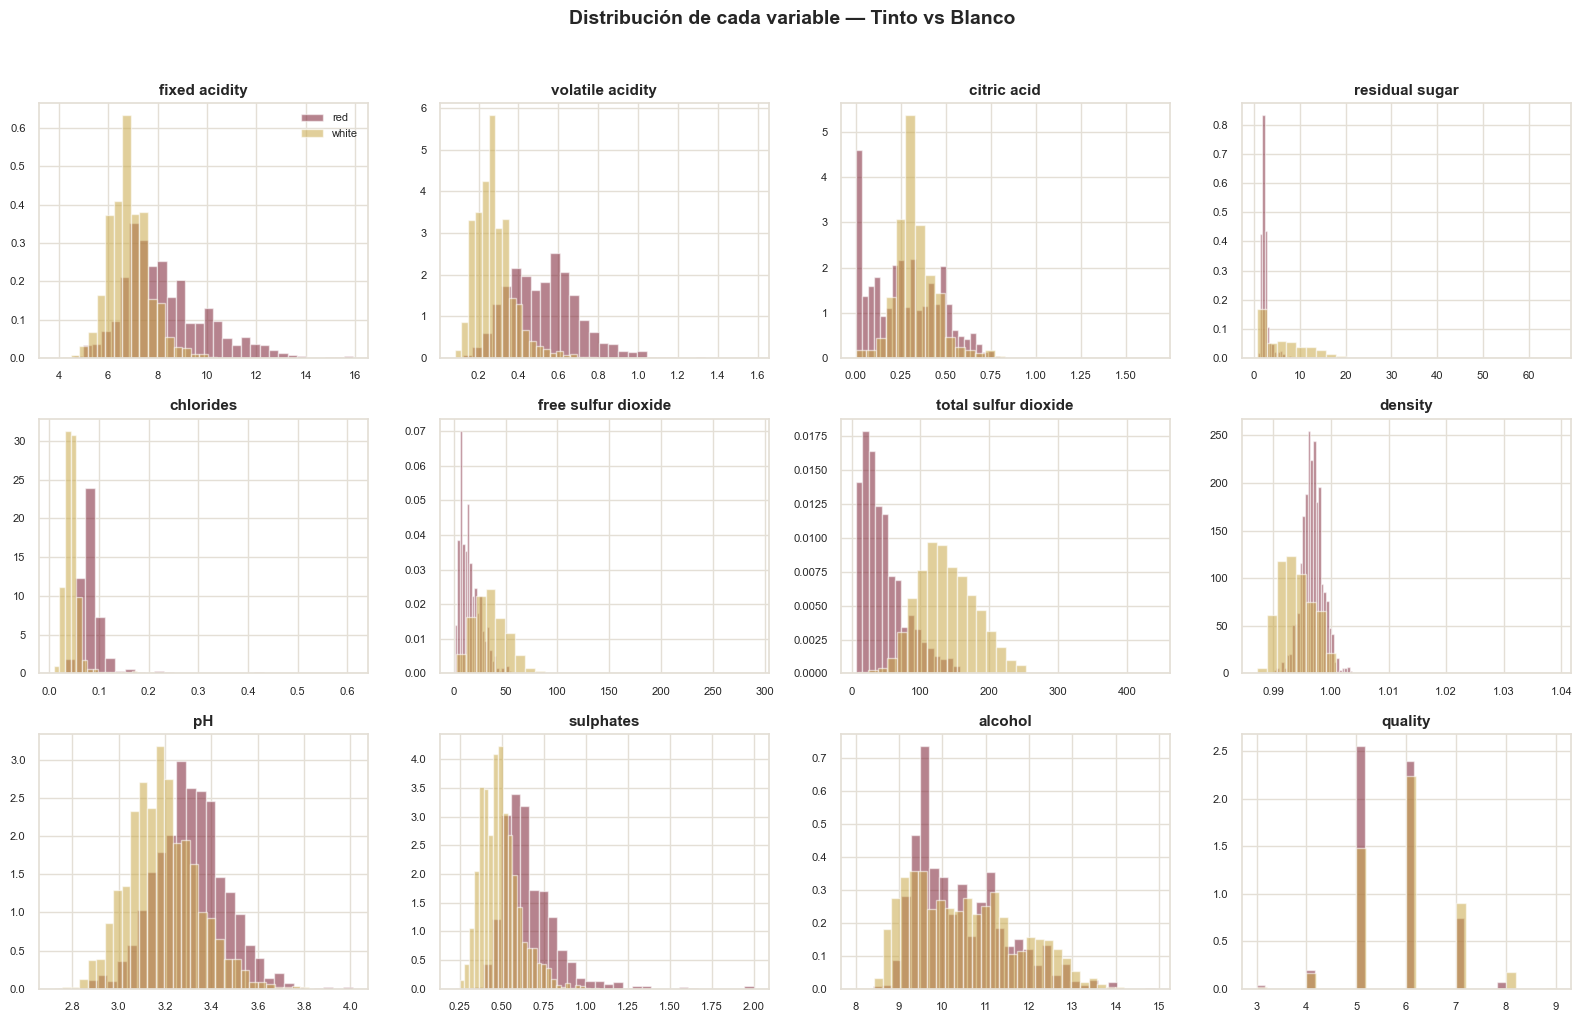

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(features + ["quality"]):
    ax = axes[i]
    for tipo, color in PALETTE.items():
        subset = df[df["tipo_vino"] == tipo][col]
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=tipo, density=True)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=8)
axes[0].legend(fontsize=8, frameon=False)
for j in range(len(features) + 1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Distribución de cada variable — Tinto vs Blanco", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


La mayoría de variables está sesgada a la derecha. Azúcar residual, SO2 libre
y densidad se ven comprimidas por unos pocos valores extremos — su forma real
se aprecia mejor en los boxplots de la sección siguiente.


## 6. Valores atípicos (outliers)

Detección con el método de rango intercuartílico (IQR): un valor se marca
atípico si cae fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.


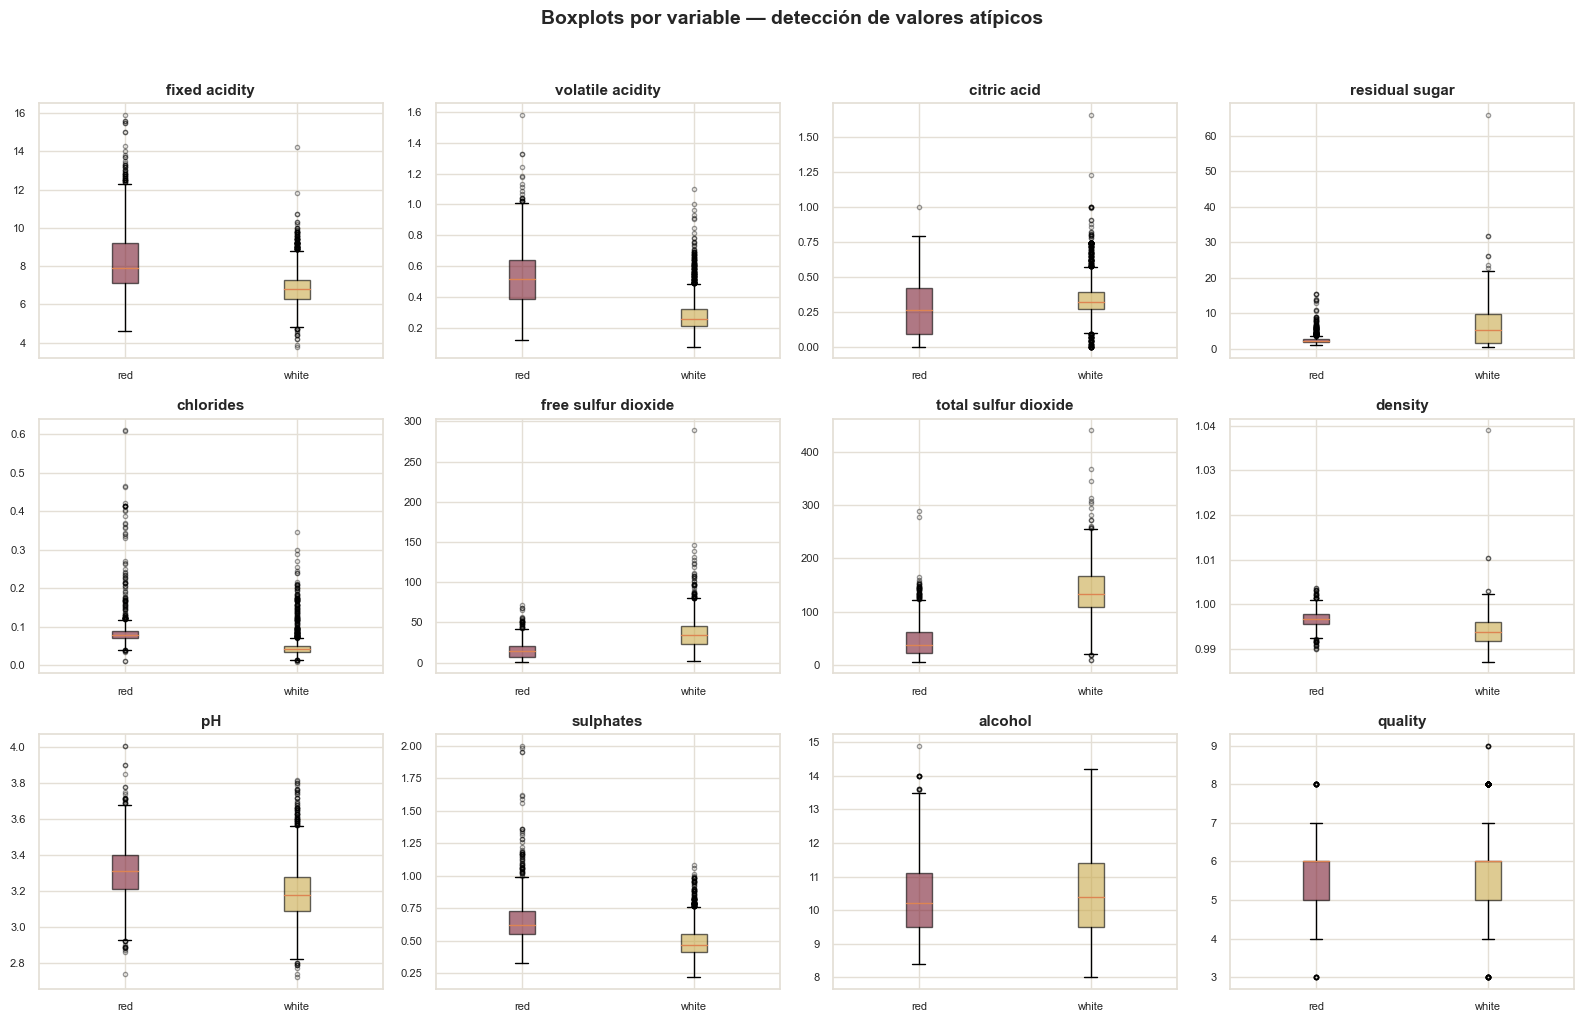

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(features + ["quality"]):
    ax = axes[i]
    data_to_plot = [df[df["tipo_vino"] == "red"][col], df[df["tipo_vino"] == "white"][col]]
    bp = ax.boxplot(data_to_plot, labels=["red", "white"], patch_artist=True,
                     flierprops=dict(marker="o", markersize=3, markerfacecolor="none", alpha=0.4))
    for patch, color in zip(bp["boxes"], [COLOR_RED, COLOR_WHITE]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=8)
for j in range(len(features) + 1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Boxplots por variable — detección de valores atípicos", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


In [10]:
outlier_rows = []
for col in features + ["quality"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    outlier_rows.append({
        "variable": col, "Q1": q1, "Q3": q3, "IQR": iqr,
        "limite_inferior": low, "limite_superior": high,
        "n_atipicos": n_out, "pct_atipicos": round(n_out / len(df) * 100, 2),
    })
outliers_df = pd.DataFrame(outlier_rows).sort_values("pct_atipicos", ascending=False)
outliers_df


,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_atipicos,pct_atipicos
2,citric acid,0.25000,0.39000,0.14000,0.040000,0.600000,509,7.83
1,volatile acidity,0.23000,0.40000,0.17000,-0.025000,0.655000,377,5.80
0,fixed acidity,6.40000,7.70000,1.30000,4.450000,9.650000,357,5.49
4,chlorides,0.03800,0.06500,0.02700,-0.002500,0.105500,286,4.40
11,quality,5.00000,6.00000,1.00000,3.500000,7.500000,228,3.51
9,sulphates,0.43000,0.60000,0.17000,0.175000,0.855000,191,2.94
3,residual sugar,1.80000,8.10000,6.30000,-7.650000,17.550000,118,1.82
8,pH,3.11000,3.32000,0.21000,2.795000,3.635000,73,1.12
5,free sulfur dioxide,17.00000,41.00000,24.00000,-19.000000,77.000000,62,0.95
6,total sulfur dioxide,77.00000,156.00000,79.00000,-41.500000,274.500000,10,0.15


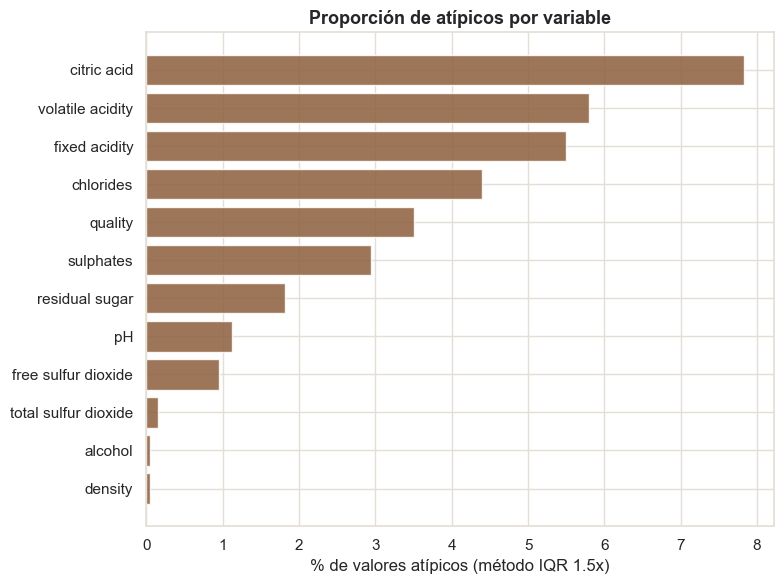

In [11]:
outlier_pct = outliers_df.set_index("variable")["pct_atipicos"].sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(outlier_pct.index, outlier_pct.values, color="#8C5E3C", alpha=0.85)
ax.set_xlabel("% de valores atípicos (método IQR 1.5x)")
ax.set_title("Proporción de atípicos por variable", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


Vale la pena inspeccionar puntualmente los casos más extremos, por ejemplo:


In [12]:
df.nlargest(3, "residual sugar")[["tipo_vino", "residual sugar", "density", "free sulfur dioxide"]]


,tipo_vino,residual sugar,density,free sulfur dioxide
4380,white,65.8,1.03898,8.0
3252,white,31.6,1.01030,35.0
3262,white,31.6,1.01030,35.0


> La fila con 65.8 g/L de azúcar residual combina, además, una densidad de
> 1.039 (fuera del rango típico de vino ~0.987–1.004). Podría ser un caso real
> (vino tipo "late harvest") o un error de captura — conviene revisarla antes
> de decidir si excluirla.


## 7. Correlaciones

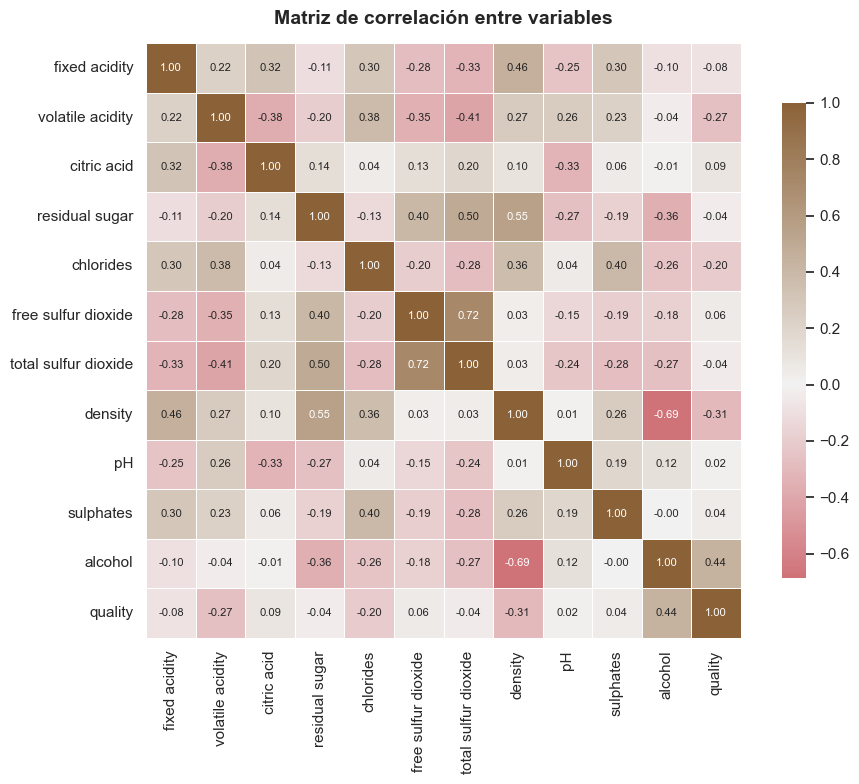

In [13]:
corr = df[features + ["quality"]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(10, 45, s=70, l=45, as_cmap=True, center="light")
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
ax.set_title("Matriz de correlación entre variables", fontsize=14, fontweight="bold", pad=14)
fig.tight_layout()
plt.show()


In [14]:
corr_quality = df[features].corrwith(df["quality"]).sort_values(key=abs, ascending=False)
corr_quality


alcohol                 0.444319
density                -0.305858
volatile acidity       -0.265699
chlorides              -0.200666
citric acid             0.085532
fixed acidity          -0.076743
free sulfur dioxide     0.055463
total sulfur dioxide   -0.041385
sulphates               0.038485
residual sugar         -0.036980
pH                      0.019506
dtype: float64

**Alcohol** es la variable más relacionada con la calidad (positiva). **Densidad**
y **acidez volátil** le siguen, ambas negativas. Ninguna correlación es fuerte en
términos absolutos — la calidad depende de una combinación de factores, no de una
sola variable dominante, y hay un componente subjetivo del catador que ninguna
variable química captura del todo.

**Colinealidad a vigilar:** SO2 libre y SO2 total están fuertemente
correlacionadas entre sí (es lógico, el libre es un subcomponente del total).
Para modelos lineales esto puede inflar la varianza de los coeficientes.


## 8. Tinto vs. Blanco

Comparación de las variables donde ambos tipos más difieren.


c:\Users\USER\miniconda3\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USER\miniconda3\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USER\miniconda3\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USER\miniconda3\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

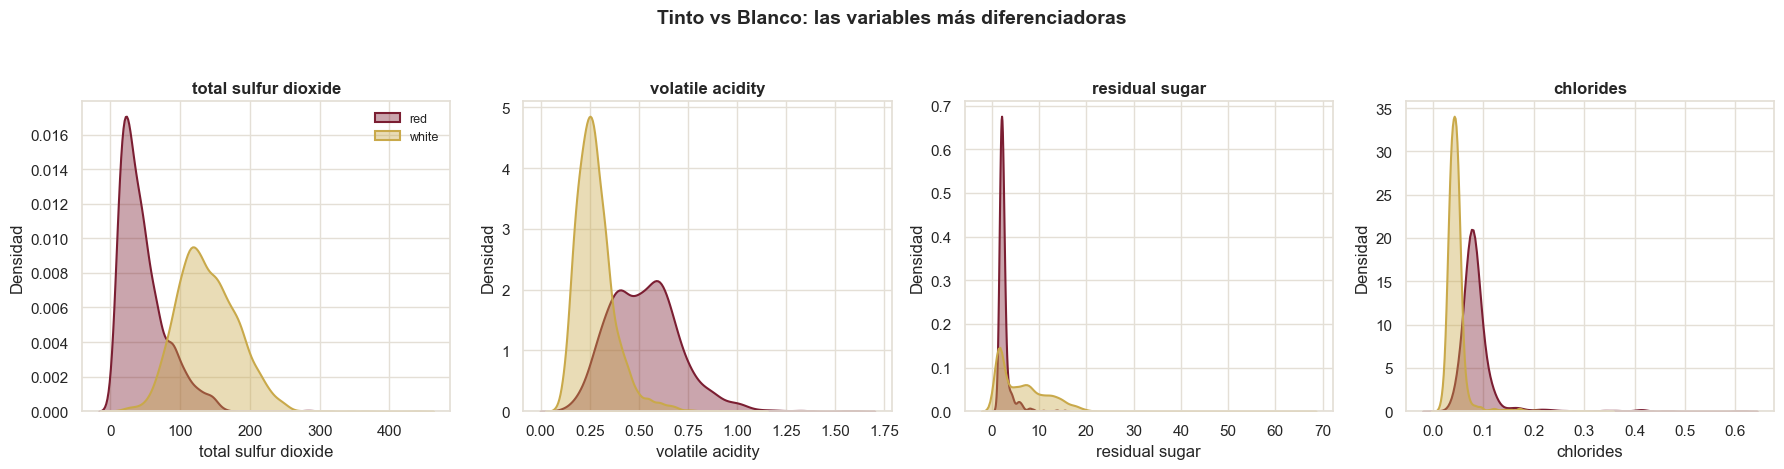

In [15]:
diff_vars = ["total sulfur dioxide", "volatile acidity", "residual sugar", "chlorides"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, diff_vars):
    for tipo, color in PALETTE.items():
        sns.kdeplot(df[df["tipo_vino"] == tipo][col], ax=ax, color=color,
                    fill=True, alpha=0.4, label=tipo, linewidth=1.5)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel("Densidad")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Tinto vs Blanco: las variables más diferenciadoras", fontsize=14, fontweight="bold", y=1.04)
fig.tight_layout()
plt.show()


- **SO2 total** es ~3x más alto en blancos — se oxidan más fácilmente al no
  fermentar con los hollejos de la uva.
- **Acidez volátil** es casi el doble en tintos — niveles altos se asocian a
  sabor a vinagre; los tintos toleran más antes de considerarse defectuosos.
- **Cloruros** son ~90% más altos en tintos.

Esta separación tan marcada explica por qué un modelo de clasificación
tinto/blanco alcanza fácilmente ~95% de accuracy con estas variables.


## 9. Calidad por tipo de vino

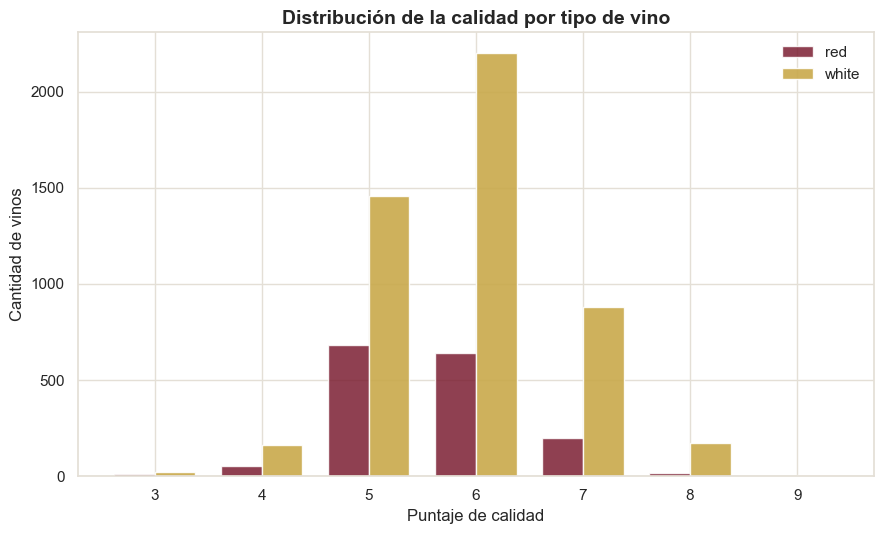

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ct = pd.crosstab(df["quality"], df["tipo_vino"])[["red", "white"]]
x = np.arange(len(ct.index))
width = 0.38
ax.bar(x - width/2, ct["red"], width, label="red", color=COLOR_RED, alpha=0.85)
ax.bar(x + width/2, ct["white"], width, label="white", color=COLOR_WHITE, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(ct.index)
ax.set_xlabel("Puntaje de calidad")
ax.set_ylabel("Cantidad de vinos")
ax.set_title("Distribución de la calidad por tipo de vino", fontsize=14, fontweight="bold")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


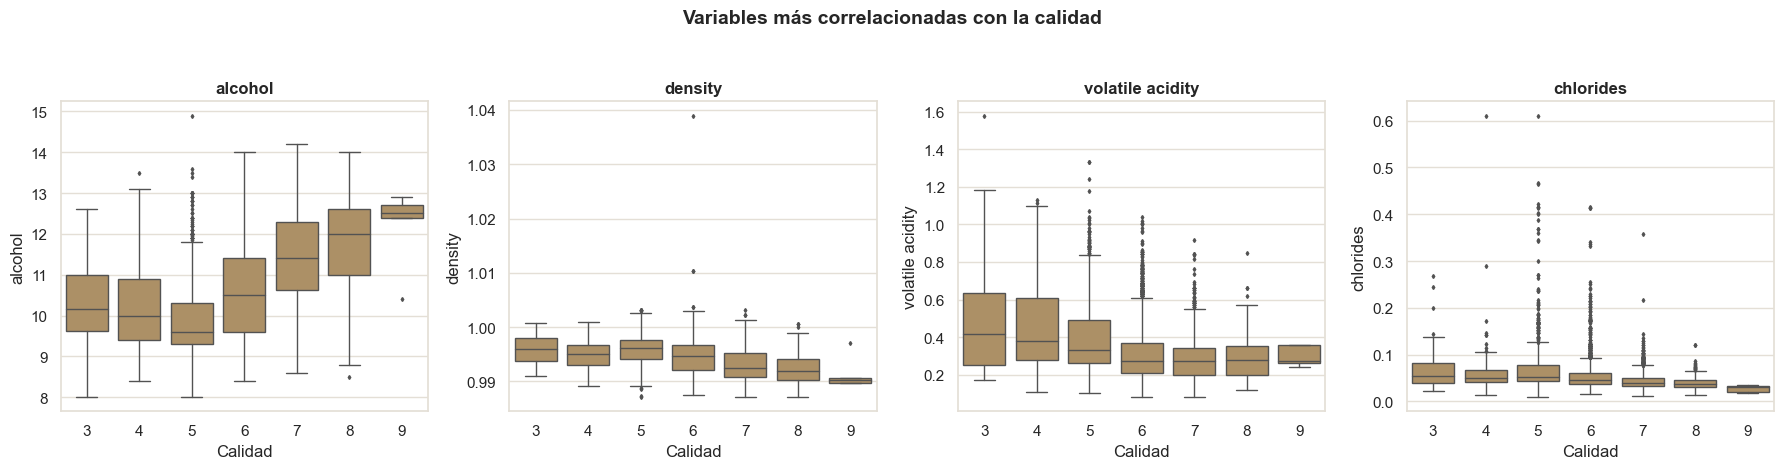

In [17]:
top_vars = ["alcohol", "density", "volatile acidity", "chlorides"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, top_vars):
    sns.boxplot(data=df, x="quality", y=col, ax=ax, color="#B8925A", fliersize=2, linewidth=1)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("Calidad")
fig.suptitle("Variables más correlacionadas con la calidad", fontsize=14, fontweight="bold", y=1.04)
fig.tight_layout()
plt.show()


La mayoría de vinos (ambos tipos) se concentra en calidad 5-6 ("promedio") —
muy pocos ejemplos en los extremos (3, 4, 8, 9), lo que limita qué tan bien
puede predecirse esa minoría de clases. El patrón de **alcohol** es el más
claro: la mediana sube de forma casi monótona con la calidad.


## 10. Conclusiones y recomendaciones

- **Sin valores faltantes** — no se requiere imputación.
- **18% de filas duplicadas** — evaluar `drop_duplicates()` antes de entrenar
  modelos, para evitar fuga de información entre train/test.
- **Atípicos presentes pero minoritarios** (0.05%–7.8% según variable) — para
  modelos basados en árboles no suelen ser un problema grave; para modelos
  lineales o basados en distancia (SVM, KNN) conviene revisar si escalar o
  recortar (winsorize) las variables con más atípicos.
- **Alcohol es el predictor individual más fuerte de calidad**, pero la
  correlación es moderada — la calidad es multifactorial y con ruido subjetivo.
- **Tinto y blanco son químicamente muy distintos** (SO2, acidez volátil,
  cloruros) — vale la pena mantener `tipo_vino` como feature o incluso
  modelar cada tipo por separado.
- **Clases de calidad desbalanceadas** (concentradas en 5-6) — cualquier
  modelo de clasificación de calidad debería usar F1 macro o balanced
  accuracy, no solo accuracy.


---
# 12. Modelado con validación cruzada correcta (Pipelines)

El EDA anterior dejó tres decisiones pendientes de aplicar: **quitar
duplicados antes de dividir los datos**, **meter el escalado dentro de un
`Pipeline`** (para que se ajuste solo con el fold de entrenamiento, nunca
con el de validación) y **decidir si tratar `quality` como regresión o
clasificación**. Esta sección hace las tres cosas y compara ambos enfoques
con los mismos datos y la misma metodología, para poder elegir con
evidencia real cuál usar.


## 12.1 Carga + la corrección clave: quitar duplicados antes de dividir

In [18]:
import time
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

RANDOM_STATE = 42

n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Filas antes de quitar duplicados: {n_antes}")
print(f"Filas despues:                    {len(df)}  (-{n_antes - len(df)}, {(n_antes-len(df))/n_antes:.1%})")


Filas antes de quitar duplicados: 6497
Filas despues:                    5320  (-1177, 18.1%)


> **Por qué esto va primero, y no dentro del `Pipeline`:** un duplicado es
> una fila *idéntica* repetida — si una copia cae en train y la otra en
> validación, el modelo ya "vio" ese dato exacto antes de que se le evalúe
> con él. Eso no es algo que un `Pipeline` pueda arreglar (el `Pipeline`
> evita fuga de *transformaciones* como el escalado, no fuga de *filas
> repetidas*), así que se limpia antes de cualquier split.


## 12.2 El preprocesador (una sola vez, reutilizado dentro de cada Pipeline)

`StandardScaler` para las numéricas y `OneHotEncoder` para `tipo_vino`.
Como va dentro de cada `Pipeline`, en cada fold de la validación cruzada se
ajusta *solo* con los datos de entrenamiento de ese fold — nunca ve el
fold de validación durante el ajuste.


In [19]:
features_num = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide",
    "density", "pH", "sulphates", "alcohol",
]
features_cat = ["tipo_vino"]

preprocesador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
])

X = df[features_num + features_cat]


## 12.3 Modelo A — Regresión (`quality` como puntaje continuo 3-9)

`KFold` (no estratificado, porque el objetivo es continuo), y `GridSearchCV`
*dentro* del mismo `Pipeline` para ajustar el hiperparámetro de cada
modelo sin fuga de datos. Se incluyen **Ridge y Lasso** explícitamente para
comparar los dos tipos de regularización, además de KNN (visto en clase)
y Random Forest.


In [20]:
y_reg = df["quality"]
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos_reg = {
    "Ridge": (Ridge(random_state=RANDOM_STATE),
              {"modelo__alpha": [0.1, 1.0, 10.0, 50.0]}),
    "Lasso": (Lasso(random_state=RANDOM_STATE, max_iter=5000),
              {"modelo__alpha": [0.001, 0.01, 0.05, 0.1]}),
    "KNN Regressor": (KNeighborsRegressor(),
                       {"modelo__n_neighbors": [5, 10, 15, 20, 30]}),
    "Random Forest": (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                       {"modelo__n_estimators": [200], "modelo__max_depth": [None, 15]}),
}

resultados_reg = {}
for nombre, (modelo, grid) in modelos_reg.items():
    pipe = Pipeline([("prep", preprocesador), ("modelo", modelo)])
    gs = GridSearchCV(pipe, grid, cv=cv_reg, scoring="r2", n_jobs=-1)
    gs.fit(X, y_reg)

    scores = cross_validate(gs.best_estimator_, X, y_reg, cv=cv_reg,
                             scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"])
    resultados_reg[nombre] = {
        "mejor_param": gs.best_params_,
        "R2_medio": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std(),
        "MAE_medio": -scores["test_neg_mean_absolute_error"].mean(),
        "RMSE_medio": -scores["test_neg_root_mean_squared_error"].mean(),
    }

tabla_reg = pd.DataFrame(resultados_reg).T.sort_values("R2_medio", ascending=False)
tabla_reg[["R2_medio", "R2_std", "MAE_medio", "RMSE_medio"]].round(4)


,R2_medio,R2_std,MAE_medio,RMSE_medio
Random Forest,0.391267,0.010808,0.526443,0.685479
KNN Regressor,0.334956,0.015414,0.560263,0.716478
Ridge,0.304866,0.015195,0.566005,0.732492
Lasso,0.304717,0.01557,0.566048,0.73257


**Hallazgo importante:** el R² del Random Forest cae a **~0.39** aquí,
frente al ~0.53 que habíamos obtenido en el análisis de validación cruzada
original (secciones anteriores de este proyecto) — esa diferencia *es*
el efecto de los duplicados que detectamos en el EDA. El ~0.53 estaba
inflado porque copias casi idénticas de una misma fila terminaban a la vez
en entrenamiento y en validación. **0.39 es la estimación correcta.**

Sobre Ridge vs. Lasso: quedan prácticamente empatados (R²=0.3049 vs.
0.3047), y el mejor `alpha` de Lasso resultó ser el más pequeño de la
grilla (0.001) — es decir, casi sin regularización. Esto indica que aquí
la regularización L1/L2 no es lo que limita al modelo lineal; el techo de
R²≈0.30 para los modelos lineales viene de que la relación entre química y
calidad simplemente no es lineal ni fuerte, no de que falte ajustar
penalización. Random Forest, al capturar no-linealidades, sube ese techo
a 0.39.


## 12.4 Modelo B — Clasificación (`quality >= 7` = "vino bueno")

Aquí sí toca `StratifiedKFold` (para mantener la proporción de clases en
cada fold) y `scoring="roc_auc"`, porque las clases están desbalanceadas.


In [21]:
y_clf = (df["quality"] >= 7).astype(int)
print("Balance de clases:", y_clf.value_counts(normalize=True).round(3).to_dict())

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos_clf = {
    "Log. Ridge (L2)": (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                         {"modelo__C": [0.01, 0.1, 1.0, 10.0]}),
    "Log. Lasso (L1)": (LogisticRegression(max_iter=2000, penalty="l1", solver="liblinear",
                                            random_state=RANDOM_STATE),
                         {"modelo__C": [0.01, 0.1, 1.0, 10.0]}),
    "KNN Classifier": (KNeighborsClassifier(),
                        {"modelo__n_neighbors": [5, 10, 15, 20, 30]}),
    "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                              class_weight="balanced"),
                       {"modelo__n_estimators": [200], "modelo__max_depth": [None, 15]}),
}

resultados_clf = {}
for nombre, (modelo, grid) in modelos_clf.items():
    pipe = Pipeline([("prep", preprocesador), ("modelo", modelo)])
    gs = GridSearchCV(pipe, grid, cv=cv_clf, scoring="roc_auc", n_jobs=-1)
    gs.fit(X, y_clf)

    scores = cross_validate(gs.best_estimator_, X, y_clf, cv=cv_clf,
                             scoring=["roc_auc", "f1", "accuracy", "average_precision"])
    resultados_clf[nombre] = {
        "mejor_param": gs.best_params_,
        "ROC_AUC_medio": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std(),
        "F1_medio": scores["test_f1"].mean(),
        "Accuracy_medio": scores["test_accuracy"].mean(),
        "PR_AUC_medio": scores["test_average_precision"].mean(),
    }

tabla_clf = pd.DataFrame(resultados_clf).T.sort_values("ROC_AUC_medio", ascending=False)
tabla_clf[["ROC_AUC_medio", "ROC_AUC_std", "F1_medio", "Accuracy_medio", "PR_AUC_medio"]].round(4)


Balance de clases: {0: 0.81, 1: 0.19}


,ROC_AUC_medio,ROC_AUC_std,F1_medio,Accuracy_medio,PR_AUC_medio
Random Forest,0.860046,0.01181,0.450298,0.843985,0.590283
KNN Classifier,0.834067,0.016132,0.396039,0.832331,0.529355
Log. Ridge (L2),0.828966,0.017849,0.388604,0.825,0.51564
Log. Lasso (L1),0.828848,0.0178,0.388913,0.824624,0.515438


Ridge y Lasso vuelven a quedar prácticamente empatados en clasificación
(ROC-AUC 0.8290 vs. 0.8288) — mismo patrón que en regresión: la elección
entre L1 y L2 casi no importa para este dataset.

Random Forest gana claramente (ROC-AUC=0.860), seguido de KNN (0.834) y
los dos modelos lineales (~0.829). El PR-AUC del mejor modelo (0.59) es
bastante más bajo que su ROC-AUC (0.86) — con solo 19% de "vinos buenos",
eso es normal y es la métrica a mirar si lo que importa es la precisión al
señalar un vino como bueno, no solo qué tan bien se ordenan.


## 12.5 Conclusión: ¿regresión o clasificación?

| | Mejor modelo | Métrica | Interpretación |
|---|---|---|---|
| **Regresión** | Random Forest | R² = 0.39 | Explica < 40% de la varianza en el puntaje exacto |
| **Clasificación** | Random Forest | ROC-AUC = 0.86 | Separa muy bien "bueno" de "no bueno" |

**Recomendación: clasificación (`quality >= 7`), con Random Forest.**

La razón no es solo que el número sea más alto — ROC-AUC y R² no se
comparan directamente porque miden tareas distintas. La razón real es que
**predecir el puntaje exacto (3 a 9) es una tarea intrínsecamente más
difícil y ruidosa** que separar dos grupos: la calidad es una mediana de
evaluaciones subjetivas de catadores, y ese ruido humano afecta mucho más
a "¿es 5, 6 o 7 exactamente?" que a "¿es claramente bueno o no?". Con las
variables fisicoquímicas disponibles, hay señal real y útil para lo
segundo (0.86 es un modelo genuinamente utilizable), pero no tanta para lo
primero (0.39 dice que la mayoría de la variación en el puntaje exacto
queda sin explicar).

Dicho esto, la elección correcta depende del uso: si el objetivo final es
*puntuar* un vino con precisión (control de calidad, pricing), regresión
sigue siendo la tarea que responde esa pregunta, aunque con un techo bajo.
Si el objetivo es *filtrar o recomendar* vinos ("¿es bueno o no?"),
clasificación es el enfoque correcto y, con estos datos, el que realmente
funciona bien.
